In [1]:
from langgraph.graph import StateGraph , START, END
from langchain_google_genai import ChatGoogleGenerativeAI
from typing import TypedDict, Annotated
from dotenv import load_dotenv
from pydantic import BaseModel,Field
import operator

In [2]:
load_dotenv()

True

In [3]:
model = ChatGoogleGenerativeAI(
    model="gemini-3.5-flash"
)

In [4]:
class EvaluationSchema(BaseModel):
    feedback : str = Field(description='detailed feedback fo the essay')
    score : int = Field(description='score out of 10', ge=0,le=10 )

In [5]:
print(EvaluationSchema.model_fields)

{'feedback': FieldInfo(annotation=str, required=True, description='detailed feedback fo the essay'), 'score': FieldInfo(annotation=int, required=True, description='score out of 10', metadata=[Ge(ge=0), Le(le=10)])}


In [6]:
structured_model=model.with_structured_output(EvaluationSchema)

In [7]:
essay ="""

India and AI Time

Now world change very fast because new tech call Artificial Intel… something (AI). India also want become big in this AI thing. If work hard, India can go top. But if no careful, India go back.

India have many good. We have smart student, many engine-ear, and good IT peoples. Big company like TCS, Infosys, Wipro already use AI. Government also do program “AI for All”. It want AI in farm, doctor place, school and transport.

In farm, AI help farmer know when to put seed, when rain come, how stop bug. In health, AI help doctor see sick early. In school, AI help student learn good. Government office use AI to find bad people and work fast.

But problem come also. First is many villager no have phone or internet. So AI not help them. Second, many people lose job because AI and machine do work. Poor people get more bad.

One more big problem is privacy. AI need big big data. Who take care? India still make data rule. If no strong rule, AI do bad.

India must all people together – govern, school, company and normal people. We teach AI and make sure AI not bad. Also talk to other country and learn from them.

If India use AI good way, we become strong, help poor and make better life. But if only rich use AI, and poor no get, then big bad thing happen.

So, in short, AI time in India have many hope and many danger. We must go right road. AI must help all people, not only some. Then India grow big and world say "good job India".
"""

In [8]:
prompt= f"evaluate the language quality of the essay and provide the feedback regarding that and also give a score out of 10 {essay}"

structured_model.invoke(
   prompt
    
)

Direct use of automatic function calling (AFC) in Models.generate_content is not recommended. Instead, we recommend to use AFC in Chat.send_message. Similarly, direct use of AFC in Models.generate_content_stream is not recommended. Instead, we recommend to use AFC in Chat.send_message_stream.


EvaluationSchema(feedback="The essay demonstrates a clear structure and a logical flow of ideas, covering the potential benefits, challenges, and future outlook of AI in India. However, the language quality is weak and requires substantial improvement. There are frequent grammatical errors, such as incorrect subject-verb agreement (e.g., 'India have many good', 'government also do'), missing articles (e.g., 'Now world change'), and awkward sentence structures (e.g., 'Poor people get more bad'). Additionally, the essay contains spelling mistakes like 'engine-ear' and highly informal language such as 'Intel... something' and 'doctor place'. To improve, focus on mastering basic grammar rules, expanding your vocabulary with professional terminology, and proofreading to eliminate spelling errors.", score=4)

In [9]:
class upscstate(TypedDict):
    essay :str
    language_feedback : str
    analysis_feedback : str
    clarity_feedback : str
    overall_feedback : str
    indiviual_scores : Annotated[list[int],operator.add]
    avg_score : float

In [10]:
def evaluate_language(state : upscstate):
    prompt= f"evaluate the language quality of the essay and provide the feedback regarding that and also give a score out of 10 {state['essay']}"
    output=structured_model.invoke(prompt)
    return {
        'language_feedback' : output.feedback,
        'indiviual_scores': [output.score]
    }

In [11]:
def evaluate_analysis(state : upscstate):
    prompt= f"evaluate the depth of analysis  of the essay and provide the feedback regarding that and also give a score out of 10 {state['essay']}"
    output=structured_model.invoke(prompt)
    return {
        'analysis_feedback' : output.feedback,
        'indiviual_scores': [output.score]
    }

In [12]:
def evaluate_clarity(state : upscstate):
    prompt= f"evaluate the clarity of thought  of the essay and provide the feedback regarding that and also give a score out of 10 {state['essay']}"
    output=structured_model.invoke(prompt)
    return {
        'clarity_feedback' : output.feedback,
        'indiviual_scores': [output.score]
    }

In [13]:
def total_feedback(state: upscstate):
     prompt = f'Based on the following feedbacks create a summarized feedback \n language feedback - {state["language_feedback"]} \n depth of analysis feedback - {state["analysis_feedback"]} \n clarity of thought feedback - {state["clarity_feedback"]}'
     output= model.invoke(prompt).content
     avg_score= sum(state['indiviual_scores'])/len(state['indiviual_scores'])
     return {
         'overall_feedback': output,
         'avg_score': avg_score
     }

In [14]:
graph = StateGraph(upscstate)
graph.add_node('evaluate_language', evaluate_language)
graph.add_node('evaluate_analysis', evaluate_analysis)
graph.add_node('evaluate_clarity', evaluate_clarity)
graph.add_node('total_feedback', total_feedback)

graph.add_edge(START,'evaluate_language')
graph.add_edge(START,'evaluate_analysis')
graph.add_edge(START,'evaluate_clarity')

graph.add_edge('evaluate_language','total_feedback')
graph.add_edge('evaluate_analysis','total_feedback')
graph.add_edge('evaluate_clarity','total_feedback')

graph.add_edge('total_feedback' ,END)

workflow=graph.compile()


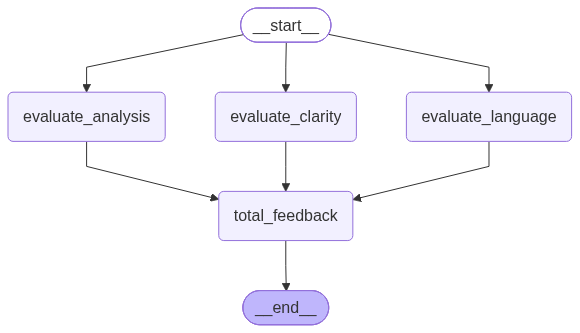

In [15]:
workflow

In [16]:
initial_state={
    'essay': essay
}

In [17]:
workflow.invoke(initial_state)

{'essay': '\n\nIndia and AI Time\n\nNow world change very fast because new tech call Artificial Intel… something (AI). India also want become big in this AI thing. If work hard, India can go top. But if no careful, India go back.\n\nIndia have many good. We have smart student, many engine-ear, and good IT peoples. Big company like TCS, Infosys, Wipro already use AI. Government also do program “AI for All”. It want AI in farm, doctor place, school and transport.\n\nIn farm, AI help farmer know when to put seed, when rain come, how stop bug. In health, AI help doctor see sick early. In school, AI help student learn good. Government office use AI to find bad people and work fast.\n\nBut problem come also. First is many villager no have phone or internet. So AI not help them. Second, many people lose job because AI and machine do work. Poor people get more bad.\n\nOne more big problem is privacy. AI need big big data. Who take care? India still make data rule. If no strong rule, AI do bad.

In [18]:
output={'essay': '\n\nIndia has evolved from a post-colonial Non-Aligned Movement leader into a pivotal emerging global power and democratic model for the developing world.  Its role is defined by a shift toward multi-alignment, balancing strategic partnerships with major powers like the US and Russia while maintaining relations with the Global South through organizations like BRICS, the G20, and the Quad. \n\nEconomically, India is the world’s fifth-largest economy and a critical driver of global growth, leveraging its vast demographic dividend and status as the "pharmacy of the world" through generic drug exports and vaccine diplomacy.  It actively promotes multilateralism and climate action, leading initiatives like the International Solar Alliance and advocating for UN Security Council reform to represent emerging economies. \n\nCulturally, India projects significant soft power via its large diaspora, spiritual heritage, and the ethos of Vasudhaiva Kutumbakam (the world is one family).  It serves as a peacekeeper and mediator in global conflicts, contributing the largest number of troops to UN peacekeeping missions, while navigating complex regional security challenges in South Asia and the Indo-Pacific through a "Neighborhood First" policy and strategic autonomy.\n\n',
 'language_feedback': "The essay exhibits exceptional language quality, characterized by sophisticated vocabulary (such as 'multi-alignment', 'demographic dividend', and 'strategic autonomy') and flawless grammatical precision. The sentence structures are diverse, elegant, and well-crafted, ensuring a smooth transition of ideas across paragraphs. The tone remains highly objective, academic, and formal, perfectly suited for a geopolitical analysis. Cohesion and coherence are outstanding throughout, making the narrative compelling and easy to follow.",
 'analysis_feedback': "The essay provides a highly comprehensive and well-structured overview of India's global role, covering key geopolitical, economic, cultural, and strategic dimensions. It successfully utilizes relevant terminology such as multi-alignment, Vasudhaiva Kutumbakam, and the Neighborhood First policy. However, the depth of analysis is limited. The essay reads more like a descriptive summary of achievements rather than a critical investigation. For instance, while it notes India's balancing act between the US and Russia, it fails to analyze the diplomatic friction and strategic trade-offs this entails in the current geopolitical climate. Similarly, it mentions regional security challenges in the Indo-Pacific without examining the specific dynamics or friction points, such as the strategic rivalry with China. To achieve greater depth, the essay needs to move beyond stating what India's policies are and critically evaluate the complexities, contradictions, and challenges India faces in executing them.",
 'clarity_feedback': "The essay exhibits exceptional clarity of thought, structured logically to trace India's evolution from historical non-alignment to contemporary multi-alignment. Each paragraph addresses a specific pillar of India's global standing: geopolitical positioning, economic and multilateral contributions, and cultural/security dimensions. The concepts are articulated with precise terminology (e.g., 'strategic autonomy', 'demographic dividend') that enhances readability. To elevate the clarity even further, the transition between distinct topics within the second paragraph (moving from economic/vaccine diplomacy to climate action and UN reform) could be slightly more explicit, as these represent different facets of global leadership. Overall, the essay is highly coherent, focused, and successfully conveys a complex geopolitical narrative in a concise manner.",
 'overall_feedback': [{'type': 'text',
   'text': "Here is a summarized feedback based on the provided evaluations:\n\n### **Executive Summary**\nThis essay is an exceptionally well-crafted and logically structured piece of geopolitical analysis. It stands out for its flawless technical execution and clear narrative flow, but would highly benefit from shifting its approach from a descriptive overview to a more critical, deep-dive evaluation of India's geopolitical challenges.\n\n### **Key Strengths**\n*   **Exceptional Language & Tone:** The essay exhibits flawless grammatical precision, a sophisticated and academic vocabulary (e.g., *'strategic autonomy'*, *'demographic dividend'*, *'multi-alignment'*), and an elegant, objective tone. \n*   **Outstanding Clarity & Structure:** The progression of thought is highly coherent, logically tracing India’s evolution from historical non-alignment to contemporary multi-alignment. Each paragraph successfully addresses a distinct pillar of India's global standing.\n\n### **Areas for Improvement**\n*   **Deepen the Critical Analysis (High Priority):** While the essay provides a comprehensive overview, it is currently too descriptive. To achieve true analytical depth, it must move beyond stating *what* policies exist and critically examine the complexities, friction points, and contradictions India faces. Specifically:\n    *   Analyze the diplomatic friction and strategic trade-offs of India’s balancing act between the US and Russia.\n    *   Examine specific regional security friction points, such as the strategic rivalry with China in the Indo-Pacific.\n*   **Smooth Internal Transitions:** While the overall narrative is cohesive, transitions between diverse topics within complex paragraphs—such as the shift from vaccine diplomacy to climate action and UN reform in the second paragraph—should be made more explicit to further enhance clarity.",
   'extras': {'signature': 'EpEhCo4hARFNMg/Dg6n3HPMh7lAleRAjoC1S7PzQN1k8IM3nAQvY0ZZBgk9QJpMDRhuU5vAdWAJCcI5hgrbhVyjJvc1wt63XvdIWsHsJA5mNW7qHFWhrDlkALkCEMVkGEa9WHF7py3Kzxkx1Q4icwtdbvjnBvjaI6sjAduXoXaig74XSwavArYm0MuZfkqbL63XiuxlSmk4gSWF0BlszpVtVKl3xWPAMfYJyyvOE601vIs8IardtqLN3iUaoVSaW1XJzihOG2ARqLfnOkAX2JhbxpZ/kP34mMS1RfAUGXOr3x/CWcEJ0F3FWQHy0jYs2qpM4X8d0MF/CmaCMTrefJ6ajw615EPFHn/q6OaaWu90/6RBlXVZpioMokpv5xyF+ueWzrNT5NRdfbqqLd8LLxMQK8sIFmqcOfuRBD0kXdUq3qYe5zsqADLOqIRhBKsSEIZKa2zqDzu1i42wsNTyuV5KNWRQoi0s+x9laQQXUHTJa+BKvm7kJyDS2hkWcG90f/vco/SshGvejYXcrnxNuKkXzg0V7zbnDBPdnlGPFOR0yF/LtIHo+trcYQablpDZBBaIwSpuhtChkiX/2W6+wfPLyfcUkQUFZoXbTNdkWJ4BJwk6GLvuxSrvNRBOVVg4g7FR8l8xXvfiuUj8kAeEQ80A16uZqPkXTvkdF6wgb14gQrjB6ad0DMseA2PF09CrIDPpfbDnu6mBZAjmB6jKd0ADHh0/dbpYrFdIgE5Y5eDG/eUSi9tZ6BI0qQ4ffJZhB/RSbGJXulcwsHchkYTwZeh74SeyLGKPJa2cpDB94v6iuZnZAZkPBLDWQNNqiI5idtsyYxyLWPYLzsfMoijxhcFf7nqnNZzDiYF0NOUrG1LV6DstQySZAQSRFj/QaCgW8Ajg/9CPILJlOUyrLfjG/oUmAyNbYHODOONStqTaJuH6Hen8T78oMaKcv5gxb/YYeDqRcg31KTdLIMJtQKFkZP1XHRTwGYVm0aahRP7CfIBQ9AYpG5bcjm9duYrgnLBtzyIuLBHvGJcLn2aREcy2Hvujxr5V4F6HTlN2wq51IqX9U1pDFgDtZ25MW8nuqHvaN42vxA8HSxNtn0ipAaUeRzQ+AzI2c41tq4YzAGl8YOdpezrQlcuLkMMfMNdInNsh05WPh5hf+iYfd+QZ555aZVvLy8etpN7zr/40oO7Pj8w/4oHQNWxRgv8cIPi5wZyjrL4zHc2MoIjnv8mw69Z1vdULvts71Zp+kUI3Mz/1VHl6lBEX0CI6qH1brEVAw2FQOwisFVn2C57RbkR8fa2iWHyaEt00xoxSQw5d+bgRkizPDVG2UODEZgJd3evic9KbjpN6yuIeosZTv5iIjunnODKSgzuMHCYTUZBZF6x3aJcakJQElw6kEp+LmmG/v/bvSKSpqxpagTOyBc8ULMP78JXziCnwRVez3rSXSEr6gUvXLs1VXX3H6pNChb0RqGoblhQE+ER+RnmTQ8NLev7I9DeI2JF5tN7Driqi3wp8RfvlJaXtiQWlIlnIg+bRuEgzLyiOgGNdd15ch77VxCxn8Z0JrdOm6NIQWtGOZ4IslThIsP1dhAGHT2aTTlMGDGw7cW6ZTyz7x0bmxtLmH/zULP1SSKHJkLFFCjvAQTkhsIXxGcIPf4h3na0QlfgcBag/OWXx9JRvpeFxkIi27i6aQsYK90MAweWFsgFVACIO5OQeRXmX/+UflbTgwAGZ/9fxhZJfhbqUiAqhQx0GDTs8LLAEOSKdIkTMyDdu/BGnrK8yKWviXzqq1rWctnZxCJLytVSrIioFTrB0Amc/cl/xMfQS64rTYmioOZgT8ysYAnGJKhNOuEDrbozOXmhqmyljIgYYzUOvL2OqaJmSfLcoBtrrIiaqesilKBEm/gbD2Q1oJcACcBN/Ik9lQy4k2IUlUuIPuCbHQDfDJ9TeoTe/0qX7pg2umJO6z1U7J/U6o34LtsK3nhjXNGy0vQXYO9rp3tPCZ8Fe56cdklLQjRaZYowEFUvz4C9opK1kNm/1xw0tA2NDUjCDVzfNvWGj3F0P0TAECL6U5JDMV6+LwWrgNDgn0VlEKL3n7OirhlIpBvhYKZogbDNLUZ4g5hKZmqTBSe4D2pN19amXeBAnsvOA2FK2bDOZmGxvIHy66rzbmS4ooTFc60dihdJ8D94nLVvlQlRFiLZXJmr2ldmN42+fR5PJ1nhY3Gm0zqe3E3wC39qIAt7tQKE6lJ5dr+8etesxpIzEl4eED+VqO/k9Ig88D417jyS1DNwqO0t3BkZPUuZdBS8hAePV/TzAjXL05Kkvgl84AO/DtAsGgHIE4hvU47igME9EP8Vauh/qw5xBvcoVZIW8tRAw9Kq4m6hu851kvJh4sFACIVhGIXbiE/fA+u9SmwaURE7MRP9ayrYAUOPWCpSG4dCnUPpVMPSRYESWb1A2h2gKWrYSscm+DaR/KsgfILEfju7YzFfsOQJhOis2OeMbnU82eqauNJG8kwoMDNVm9+flWNTXNMcuRgyf3o3J46Jsdee97CblUKIm5uRQOYpPvKF+AkpbqYiV2HBHrPhFA6w6hFst4XXcLmQpBmCvt+OG2G3tLS9Ty7B9zaDlBcc3eQhEvjr/4smFZscrD5FEFGAFvMXix7h9zcoAyslNmUwV6k5jUiQHbL+6NXjcG1x4ncwNd5aDLiIkirpuyd8u2vGhdxWnds5tTckX1wHwLl+o9eO4DqDB8mWyznAhtYPThcqBY/aO+XCvQ8ScxMchf3UJqUZmJpUY2Qi+tG44niFVYPi8p0tUtYHfc2GF3Z/ibodgczgn13yg1zZfrHdilxLazjQ3r4p/W9vOoVxCfscRmJc6PAdchWer6oVMjNJerT9hDdQ4Mw8F9SECGFZQMjoDLSc6SkJJBUi6FrI8W1PGkq6OGwTiNoESjL+oRDFqljbFLEqH0YLpVCms2CdpVd5yxXzobNSPYaHJPwor5OyzFv2qhD13iqR/Ca5+Z5PDccRc1B3u/jgUVb7eVkxm7dhlwoK82K20aKDITAeAAsPz6qfkdoOWOv4v8AQ5M86z3a2OhVOptoiC45nco3tPrDyadrsIZ/3eVp8lIggv+4Y9pKUAVQ0pnOTumHxf7BZzkoQHAMRAGvt0u7y93R5nZLq7RH1T6Jjmyxo2spCDiSBg/sxuJRGrYw94pDzhbHAnIHOVpLpRrm7YldC7ZLlNfz8iSZI38rTwZ2oqGsj+bczSZydRr7WnvepC+JiZY7yRNidfbThDVyTxKBT26j2O955RM5W4nIETJQ9r/fU5MVGSHi67xecbd7HDPxSxqR7z//bTf6MnH3D57+LKgbrG6PuL1JDGprkgnfJ60pIYkOIa1mganZsPgBFaY9Av0XZjOCPg+9KuC4DDNy9+zHga2/lrcXyOy2djXcLLk0fjFlC6TVwpwzUeLG1cAeqfu76K/QlzgiH5YEmqSFn2TPR147ErAHM45vjL5INR3ifr5qnjlTjsKubpYEszWoZ2dJ475abWTj22qOJxkIASQYBG4Vv+3DguuuLINeK0JX9hP8RuLTYZk2wOzCA0Fe4qN+EUgW7Fvwb0HWVHFRcRB3Yg7evHvj5FZdIFh3udG3OzQQx35f4lD4kH2QcNtXCvkqGGCBZONx7eeav0+a/Q8ior46ZduDwYQz4vA3D87EaNAOrCYkAob2/qA+UWn9w8L1Qu5e1I3oeiZsQAMFywardeoQYPpgn8Z9C9tX1knFH/QbW8Vqaz8ttOSd+6vKDSyuVw0ehbmrNePK3OT1HaPURb4QMZ3GMPEvQKrizcc9xMmL6qEG/JWhaRLThNcgnycG92QXa7cpXzlp2rBLeGswOmNldgaO/TMiB7bnvFKXvj4Qn0sTWvOxjo7Zm9TQYBo4EDPAkTAJjO53DkdDLSyMjYgk7Eia7EB4LO7eD7QbQD5kkkZ+5TuEK2zmnvS6NcXwyc5nTT8MNvTGUbwFwivh0Du8IKFnGaYR/v+HLjQ6Sv9JHSuXRm8OkcWxbwiEfaJDg3vhkGVksV7Bdt4ydPwEv5h/WikZviONG8+AzUIEfCmlmeoZq+d/42UbWOjoYmqICirtC82N+ZPtxrT5QnLVLPgyjp9L+GdaRRWND1o5x0BK4TguCQ3k65CBS9smrOvkV2Hg6Ho8wQF18+i525yFOSxktYWSRYG5aSFjNNa1OCGrd89K9ge2LNoxlosacJcOGq1L7FvLu3NjYa10VGbZfgUVaYnU+Fv4L735QNe+B/8pj4PlY4JRInrdsTz61kYvF78wgK0dFG+E0tB/5gDZHu2fUVXR6qJUdkFf+IbY+q6LnzY4TpTSBU0EG+XZzLlfheD4O1aUA8y4zSxV8gTN2I09C9dLpJyJQQEjZVWMfJljxWAkZ1XFTP5RCCbnaBgVH5Xzir8llO/GSPkgUmGGnlAsoBCbB3OHzvEomE8aPm93d7ySQzteVOfrnUZLZebVbdKto6G+P6mmYsIYRSh4THqQoHgpKMH8xONjLdK34r7Wo8WJ7/bYhiTQzCfDWaHEHoylHEeKV6JS2z2eFx6IlJBo4fLzYrErHtVkCVi2wNUD/AAW8i4IFQFuEmYvpr/cNigXFKcjm0uXsY5q9rfDqSnGuzItQgDb/E6yICNt1zyEENpu5wVX0vvK0KkYRC55yafCpZA8WUMeZvGtjmIgVlwSw/aqGT1q+MlWQ85PNmhVOTweN+AUEG/8YK5xfBDxmvIXT2kJYx9WtWkJmLJ94SHEkFxzB7Y7BaK8hMtK1JeRDhPDMaGdr6bi6SY/q4Ds65r0CD01t6Uu4FOvtuG2D184RHFZJNCC3o7I/m2CM54aSimarnYsFQpUiCDODdvyxdn8mRrtxmiLvRRISRNqlmV/pcyiGhfGBlNHS+GqyzEXSa4RqcZI/pluuez/kiP4mZH9EDronV5/J8+3yufe0F+c9osqOWJ1DKodj+gN1+Sx8y9hbXffVs9zYPiDJ96sc/hHvfyVzIXP6tqCoy9mrWkV595yWWYNn5WyfOP6RKHllGhBgBAa57JhCFP3L5IbLVYH9lMpcBd6isL23XhEk9r2IPXPtl77gDcmlYi4PO+86J9JuEvuZvfMPrs0083DhHEY2uJkjNZgHemdPCOCFYcFrtrM4rO68q55P/iww6XGmqv8MT+nBDuuyjd60FpiQL922VT0nD5CGVgHx/gN1WcIp3av+2eUnVjFx9uKb+C+35suoUjTZXxFYhBidkgVOppMxfxT2SyBAkn6MCL/tu1O+sxBxtu4yIqIOSsqMoo43IqsKxQPlEMzpBcD0+ceuHdJzpGrMjUa8Kk5qoYQGcTShBe7FHDIxO9AiPs72HSOQNEihh6AvS9jC/XdCRm/gdMOxbV6yJqUsLh59+A+Prfbn9Ajr0x3u8JgEeh6gaVOkhvOFfD/Pxrfzz+TsA+c4gEcO1c5XiIHZySzQLRFfXszdubPxI2lOStel1tMzCYtj8auJ8sJKDAdPbYWDNo9J1vLtgK9GDR+WjJCpSWIJdCXB5mginKpAJp80qeBMllwCQZPVUn5zb1r+kIrR0h2zrijoHjNNZ7ODP5+2jWwo9I6YXuYc6UgffGYJCkhHXDE3nwhfolTJpu3m33e81sn4v0Bk7J92BnWX26pKfBkQJ/p+4227TCcuZYPAAJ9rBAStA='}}],
 'indiviual_scores': [6, 9, 10],
 'avg_score': 8.333333333333334}

In [19]:
del output['overall_feedback'][0]['extras']

In [20]:
output

{'essay': '\n\nIndia has evolved from a post-colonial Non-Aligned Movement leader into a pivotal emerging global power and democratic model for the developing world.  Its role is defined by a shift toward multi-alignment, balancing strategic partnerships with major powers like the US and Russia while maintaining relations with the Global South through organizations like BRICS, the G20, and the Quad. \n\nEconomically, India is the world’s fifth-largest economy and a critical driver of global growth, leveraging its vast demographic dividend and status as the "pharmacy of the world" through generic drug exports and vaccine diplomacy.  It actively promotes multilateralism and climate action, leading initiatives like the International Solar Alliance and advocating for UN Security Council reform to represent emerging economies. \n\nCulturally, India projects significant soft power via its large diaspora, spiritual heritage, and the ethos of Vasudhaiva Kutumbakam (the world is one family).  I